In [22]:
# [Cell 1] 环境配置、物理拓扑与全局控制 (Jupyter 独立运行基石)
# ==============================================================================
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import random


# ------------------------------------------
# 🔒 1. 核心控制台：锁定所有随机性
# ------------------------------------------
def set_seed(seed=42):
    """锁定 PyTorch、Numpy 和 Python 所有的底层骰子"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def get_obs_indices(num_nodes=33, seed=42):
    """动态但固定地生成 15% 观测点 (永远包含 0 号平衡节点)"""
    random.seed(seed)  # 局部锁死
    num_obs = int(num_nodes * 0.15)  # 33节点约 4.95 -> 4 个附加点 + 1 个平衡点 = 5 个点
    all_idx = list(range(1, num_nodes))
    return [0] + sorted(random.sample(all_idx, num_obs - 1))


# 初始化全局状态
set_seed(42)
global_obs_indices = get_obs_indices(33, 42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 炼丹炉就绪! 算力: {device}")
print(f"📡 锁定的 15% PMU 观测点: {global_obs_indices}")

# ------------------------------------------
# ⚡ 2. 提取 33 节点导纳矩阵 Ybus
# ------------------------------------------
branch_data = np.array([
    [1, 2, 0.00057, 0.00029], [2, 3, 0.00307, 0.00156], [3, 4, 0.00228, 0.00117],
    [4, 5, 0.00237, 0.00121], [5, 6, 0.00511, 0.00441], [6, 7, 0.00116, 0.00336],
    [7, 8, 0.00443, 0.00146], [8, 9, 0.00642, 0.00461], [9, 10, 0.00651, 0.00461],
    [10, 11, 0.00122, 0.00040], [11, 12, 0.00233, 0.00074], [12, 13, 0.00915, 0.00720],
    [13, 14, 0.00337, 0.00444], [14, 15, 0.00368, 0.00328], [15, 16, 0.00465, 0.00340],
    [16, 17, 0.00804, 0.01073], [17, 18, 0.00456, 0.00358], [2, 19, 0.00102, 0.00097],
    [19, 20, 0.00938, 0.00845], [20, 21, 0.00255, 0.00298], [21, 22, 0.00442, 0.00584],
    [3, 23, 0.00281, 0.00192], [23, 24, 0.00560, 0.00442], [24, 25, 0.00559, 0.00437],
    [6, 26, 0.00126, 0.00064], [26, 27, 0.00177, 0.00090], [27, 28, 0.00660, 0.00582],
    [28, 29, 0.00501, 0.00437], [29, 30, 0.00316, 0.00161], [30, 31, 0.00608, 0.00600],
    [31, 32, 0.00193, 0.00225], [32, 33, 0.00212, 0.00330]
])

num_nodes = 33
y_bus = np.zeros((num_nodes, num_nodes), dtype=complex)
for i in range(len(branch_data)):
    f, t = int(branch_data[i, 0] - 1), int(branch_data[i, 1] - 1)
    y_line = 1 / (branch_data[i, 2] + 1j * branch_data[i, 3])
    y_bus[f, f] += y_line
    y_bus[t, t] += y_line
    y_bus[f, t] = y_bus[t, f] = -y_line

G_tensor = torch.tensor(y_bus.real, dtype=torch.float32).to(device)
B_tensor = torch.tensor(y_bus.imag, dtype=torch.float32).to(device)


# ==============================================================================
# [Cell 2] 核心武器库：物理方程、网络架构与观测控制 (Jupyter 独立版)
# ==============================================================================

# ------------------------------------------
# 1. 物理考卷控制：随机但可控地抽取观测点
# ------------------------------------------
def get_obs_indices(num_nodes=33, seed=42):
    """
    不管在哪个单元格运行，只要 seed 一样，选出的 15% 观测点位置就一模一样。
    """
    random.seed(seed)
    num_obs = int(num_nodes * 0.15)  # 约 5 个点
    all_idx = list(range(1, num_nodes))  # 排除平衡节点
    # 强制包含 0 号平衡节点，剩下随机抽
    return [0] + sorted(random.sample(all_idx, num_obs - 1))


# ------------------------------------------
# 2. 盲区遮蔽引擎：模拟只有 15% 传感器的数据流
# ------------------------------------------
def apply_blind_zone(batch_x, obs_indices, mean_t, scale_t):
    """
    把非观测节点的数据全部抹成“物理零点（均值）”，实现空间维度的遮蔽。
    """
    physical_zero_std = (0.0 - mean_t) / scale_t
    masked_x = physical_zero_std.repeat(batch_x.shape[0], 1)
    for idx in obs_indices:
        masked_x[:, idx] = batch_x[:, idx]  # P 注入
        masked_x[:, idx + 33] = batch_x[:, idx + 33]  # Q 注入
    return masked_x


# ------------------------------------------
# 3. 潮流方程引擎：PyTorch 矩阵化计算 (KCL 的神经网络实现)
# ------------------------------------------
def calculate_physics_p_torch(V_pred, theta_pred, G_t, B_t):
    """
    核心：通过电压幅值和相角差，利用导纳矩阵反推节点 P, Q
    """
    delta_theta = theta_pred.unsqueeze(2) - theta_pred.unsqueeze(1)
    cos_matrix = torch.cos(delta_theta)
    sin_matrix = torch.sin(delta_theta)

    # 物理算子: G*cos + B*sin
    p_term = G_t * cos_matrix + B_t * sin_matrix
    q_term = G_t * sin_matrix - B_t * cos_matrix

    # 全局加权求和
    sum_p = torch.sum(V_pred.unsqueeze(1) * p_term, dim=2)
    sum_q = torch.sum(V_pred.unsqueeze(1) * q_term, dim=2)

    P_calc = V_pred * sum_p
    Q_calc = V_pred * sum_q
    return P_calc, Q_calc


# ------------------------------------------
# 4. R-PINN 网络架构：带 Asymmetric Residual Scaling (ARS)
# ------------------------------------------
class PowerGridPINN(nn.Module):
    def __init__(self, input_dim=66):
        super(PowerGridPINN, self).__init__()
        self.hidden_layers = nn.Sequential(
            nn.Linear(input_dim, 256), nn.SiLU(),
            nn.Linear(256, 256), nn.SiLU(),
            nn.Linear(256, 256)
        )
        self.output_layers = nn.Linear(256, 66)

    def forward(self, x):
        features = self.hidden_layers(x)
        output = self.output_layers(features)

        # --- 核心 ARS 机制 ---
        # 标幺值系统电压在 1.0 附近，相角在 0 附近，残差学习极大加速收敛
        Vm_pred = output[:, :33] * 0.1 + 1.0
        theta_pred = output[:, 33:] * 0.01 + 0.0

        # 锚定平衡节点常识：Bus 0 永远是 (1.0, 0.0)
        Vm_pred[:, 0] = 1.0
        theta_pred[:, 0] = 0.0
        return Vm_pred, theta_pred


# ------------------------------------------
# 5. 联合 Loss 函数：数据锚定 + 物理一致性 + 电压墙
# ------------------------------------------
class PowerPINNLoss(nn.Module):
    def __init__(self, G, B, obs_idx):
        super(PowerPINNLoss, self).__init__()
        self.G, self.B, self.obs_idx = G, B, obs_idx
        self.mse_tool = nn.MSELoss()

    def forward(self, V_pred, theta_pred, P_real_target, Q_real_target, V_real, p_weight, obs_weight=500000):
        # 1. 潮流物理残差 (KCL 约束)
        P_calc, Q_calc = calculate_physics_p_torch(V_pred, theta_pred, self.G, self.B)
        P_loss = self.mse_tool(P_calc, P_real_target)
        Q_loss = self.mse_tool(Q_calc, Q_real_target)

        # 2. 观测点数据偏差 (蓝星锚定)
        V_obs_pred = V_pred[:, self.obs_idx]
        V_obs_real = V_real[:, self.obs_idx]
        obs_loss = torch.sum((V_obs_pred - V_obs_real) ** 2)

        # 3. 边界壁垒 (防止电压越限)
        # 用 ReLU 实现：如果电压在 0.85-1.1 之间，Loss=0；否则罚得它亲妈都不认识
        penalty_low = torch.nn.functional.relu(0.85 - V_pred)
        penalty_high = torch.nn.functional.relu(V_pred - 1.1)

        return (
                p_weight * (P_loss + Q_loss) +
                1000 * torch.mean(penalty_low + penalty_high) +
                obs_weight * obs_loss
        )


# ------------------------------------------
# 6. 数据装载器
# ------------------------------------------
class MyDataset(Dataset):
    def __init__(self, features, labels):
        self.features = features
        self.labels = labels

    def __len__(self): return len(self.labels)

    def __getitem__(self, idx): return self.features[idx], self.labels[idx]


print("✅ Cell 2 [完全体] 加载完毕！物理引擎、网络架构和独立种子机制已全部就位。")
# ==========================================
# [Cell 3] 数据引擎：脱水、归一化与全链条种子锁定
# ==========================================

# 🚀 绝杀操作：在加载数据前再次重置种子，确保 DataLoader 的 shuffle 逻辑被物理锁死
set_seed(42)

print("📥 正在从本地磁盘读取 50,000 条 33 节点物理样本...")
# 注意：路径请保持你电脑上的原始路径
df = pd.read_csv(r'D:\PycharmWork\pythonProject\IEEE33_50000_Safe_Final.csv')
raw_data = df.values
m = raw_data.shape[0]

# 1. 物理维度重塑 [样本数, 节点数, 特征数(P, Q, V, Theta)]
data_3d = raw_data.reshape(m, 33, 4)

# 2. 物理脱水：兆瓦(MW/MVar) -> 标幺值(p.u.) 
# 这一步极其专业，让物理方程的数值量级保持在 [0, 1] 之间
P_real_pu = data_3d[:, :, 0].copy() / 100.0  # 基准功率取 100MVA
Q_real_pu = data_3d[:, :, 1].copy() / 100.0
V_real_pu = data_3d[:, :, 2].copy()  # 电压本来就是标幺值

# 3. 输入特征归一化 (StandardScaler)
# AI 喜欢零均值、单位方差的数据，这能让 Loss 降得更快
X_raw = data_3d[:, :, 0:2].reshape(m, 66)  # 展开成 66 维输入
ssl = StandardScaler()
X_norm = ssl.fit_transform(X_raw)

# 4. 提取归一化参数，转化为 Tensor 供 apply_blind_zone 使用
# 这样在盲区遮蔽时，我们才能把盲区节点准确地抹成“统计学零点”
mean_tensor = torch.tensor(ssl.mean_, dtype=torch.float32).to(device)
scale_tensor = torch.tensor(ssl.scale_, dtype=torch.float32).to(device)

# 5. 目标值拼装 [P(33), Q(33), V(33)] -> 总共 99 维
PQV_target_up = np.concatenate([P_real_pu, Q_real_pu, V_real_pu], axis=1)

# 6. 转化为 GPU 计算张量
X_tensor = torch.tensor(X_norm, dtype=torch.float32).to(device)
PQ_target_tensor = torch.tensor(PQV_target_up, dtype=torch.float32).to(device)

# 7. 创建数据集与装载器
# 这里的 generator 是为了二次锁死 DataLoader 内部的随机洗牌顺序
g = torch.Generator()
g.manual_seed(42)

train_dataset = MyDataset(X_tensor, PQ_target_tensor)
train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True,  # 虽然是洗牌，但因为有种子，洗牌的顺序是永久固定的
    generator=g  # 锁定洗牌发生器
)

print("-" * 50)
print(f"✅ 数据引擎装载完毕！")
print(f"📊 样本总数: {m} | 输入维度: 66 | 目标维度: 99")
print(f"🔒 数据洗牌顺序已锁定，实验可复现性：100%")
print("-" * 50)

🚀 炼丹炉就绪! 算力: cuda
📡 锁定的 15% PMU 观测点: [0, 2, 8, 18]
✅ Cell 2 [完全体] 加载完毕！物理引擎、网络架构和独立种子机制已全部就位。
📥 正在从本地磁盘读取 50,000 条 33 节点物理样本...
--------------------------------------------------
✅ 数据引擎装载完毕！
📊 样本总数: 50000 | 输入维度: 66 | 目标维度: 99
🔒 数据洗牌顺序已锁定，实验可复现性：100%
--------------------------------------------------


In [21]:
# ==============================================================================
# [Cell 7] 鲁棒性终极测试 (PMU Measurement Noise Test)
# 目的：给 15% 的 PMU 传感器注入高斯白噪声，验证物理约束的极限抗干扰能力
# ==============================================================================

# 🚀 1. 考卷定格：强制对齐观测点
set_seed(42) 
obs_indices = get_obs_indices(33, 42) 
TEST_NOISE_LEVEL = 0.01

print(f"🚀 [鲁棒性测试] 启动 | 当前 PMU 噪声水平: {TEST_NOISE_LEVEL*100}% | 观测点: {obs_indices}")

# 2. 实例化全新的测试模型与 Loss
model_noise = PowerGridPINN(input_dim=66).to(device)

# 3. 初始化偏置
with torch.no_grad():
    model_noise.output_layers.bias[:33].fill_(-0.5)

pinn_loss_noise = PowerPINNLoss(G_tensor, B_tensor, obs_indices)
optimizer_noise = torch.optim.Adam(model_noise.parameters(), lr=0.001)
scheduler_noise = torch.optim.lr_scheduler.StepLR(optimizer_noise, step_size=40, gamma=0.5) 

# 4. 深度训练循环 (带噪声注入)
max_epoch = 150
for epoch in range(max_epoch):
    p_weight = 1000 if epoch < 50 else 5000
    model_noise.train()
    
    running_loss = 0.0
    for batch_x, batch_all_targets in train_loader:
        optimizer_noise.zero_grad()
        
        # 解析真实值
        real_p = batch_all_targets[:, :33]
        real_q = batch_all_targets[:, 33:66]
        real_v = batch_all_targets[:, 66:]
        
        # 应用 15% 观测遮蔽
        mask_x = apply_blind_zone(batch_x, obs_indices, mean_tensor, scale_tensor)
        
        # 模型推理 (V_guess)
        V_guess, theta_guess = model_noise(mask_x)
        
        # ========================================================
        # ⚠️ 核心：精准切片注入传感器噪声
        noisy_V = real_v.clone()
        clean_obs_v = noisy_V[:, obs_indices] # 提取 15% 真实观测值
        
        # 生成对应形状的随机高斯矩阵，并按比例注入
        noise_matrix = torch.randn_like(clean_obs_v) * TEST_NOISE_LEVEL
        noisy_V[:, obs_indices] = clean_obs_v + clean_obs_v * noise_matrix
        # ========================================================

        # 核心：用被污染的 noisy_V 去计算观测 Loss，骗过网络
        loss = pinn_loss_noise(V_guess, theta_guess, real_p, real_q, noisy_V, p_weight, obs_weight=500000)
        
        loss.backward()
        optimizer_noise.step()
        running_loss += loss.item()
    
    scheduler_noise.step()
    if epoch % 10 == 0:
        print(f"Epoch {epoch:<3} | Avg Loss: {running_loss/len(train_loader):.4f} | LR: {optimizer_noise.param_groups[0]['lr']}")

# 5. 最终指标结算 (依然用最干净的 real_Vm 来算误差！)
model_noise.eval()
with torch.no_grad():
    test_X = X_tensor[:1000]
    real_Vm = data_3d[:1000, :, 2]
    masked_test_X = apply_blind_zone(test_X, obs_indices, mean_tensor, scale_tensor)
    
    pred_Vm_noise_tensor, _ = model_noise(masked_test_X)
    pred_Vm_noise = pred_Vm_noise_tensor.cpu().numpy()
    
    error_noise = pred_Vm_noise - real_Vm
    mae_noise = np.mean(np.abs(error_noise))
    rmse_noise = np.sqrt(np.mean(error_noise**2)) # 👈 仅在这里为你新增了RMSE的计算

print("\n" + "="*65)
print(f"🛡️ [鲁棒性测试结果] Noise Level: {TEST_NOISE_LEVEL*100}%")
print("-" * 65)
print(f"🌍 MAE under {TEST_NOISE_LEVEL*100}% Noise:  {mae_noise:.6e} p.u.")
print(f"🔥 RMSE under {TEST_NOISE_LEVEL*100}% Noise: {rmse_noise:.6e} p.u.") # 👈 仅在这里为你新增了RMSE的打印输出
print("="*65)

# ==========================================
# 6. 学术级英文绘图 (抗噪声表现)
# ==========================================
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['axes.unicode_minus'] = False
plt.style.use('seaborn-v0_8-paper') 

sample_idx = 10 
v_true = data_3d[sample_idx, :, 2]

with torch.no_grad():
    test_input = X_tensor[sample_idx:sample_idx+1]
    masked_input = apply_blind_zone(test_input, obs_indices, mean_tensor, scale_tensor)
    v_p_noise_plot = model_noise(masked_input)[0].cpu().numpy().flatten()

nodes = np.arange(33)
plt.figure(figsize=(10, 5), dpi=300) 

plt.axvspan(0, 32, color='gray', alpha=0.1, label='Blind Zone')

# 画出绝对真理和扛着噪声跑出来的结果
plt.plot(nodes, v_true, 'k-o', label='Ground Truth', markersize=4, linewidth=1.5)
plt.plot(nodes, v_p_noise_plot, 'r--^', label=f'R-PINN (with {TEST_NOISE_LEVEL*100}% Noise)', markersize=5, linewidth=1.5)

plt.scatter(obs_indices, v_true[obs_indices], color='blue', marker='*', s=180, zorder=5, label='Noisy Sensors')

plt.title(f"Robustness Analysis on IEEE 33-Bus (Sample #{sample_idx}, PMU Noise = {TEST_NOISE_LEVEL*100}%)", fontsize=14, fontweight='bold')
plt.xlabel("Bus Index", fontsize=12)
plt.ylabel("Voltage Magnitude (p.u.)", fontsize=12)
plt.ylim(0.9, 1.05) 
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='best', fontsize=10, frameon=True)
plt.tight_layout()

# 保存带噪声水平后缀的高清图
plt.savefig(f'ieee33_robustness_{int(TEST_NOISE_LEVEL*100)}percent.png', dpi=600)
plt.show()

🚀 [鲁棒性测试] 启动 | 当前 PMU 噪声水平: 1.0% | 观测点: [0, 2, 8, 18]
Epoch 0   | Avg Loss: 312014.0586 | LR: 0.001


KeyboardInterrupt: 

🚀 [鲁棒性测试] 启动 | 当前 PMU 噪声水平: 2.0% | 观测点: [0, 2, 8, 18]
Epoch 0   | Avg Loss: 385965.1657 | LR: 0.001
Epoch 10  | Avg Loss: 98760.3555 | LR: 0.001
Epoch 20  | Avg Loss: 98648.0075 | LR: 0.001
Epoch 30  | Avg Loss: 98667.7341 | LR: 0.001
Epoch 40  | Avg Loss: 99043.4641 | LR: 0.0005
Epoch 50  | Avg Loss: 99808.7189 | LR: 0.0005
Epoch 60  | Avg Loss: 100034.9551 | LR: 0.0005
Epoch 70  | Avg Loss: 100200.1573 | LR: 0.0005
Epoch 80  | Avg Loss: 99390.2237 | LR: 0.00025
Epoch 90  | Avg Loss: 99141.2974 | LR: 0.00025
Epoch 100 | Avg Loss: 99970.8916 | LR: 0.00025
Epoch 110 | Avg Loss: 99433.5768 | LR: 0.00025
Epoch 120 | Avg Loss: 99814.6603 | LR: 0.000125
Epoch 130 | Avg Loss: 99708.6930 | LR: 0.000125
Epoch 140 | Avg Loss: 99959.6883 | LR: 0.000125

🛡️ [鲁棒性测试结果] Noise Level: 2.0%
-----------------------------------------------------------------
🌍 MAE under 2.0% Noise:  3.144423e-03 p.u.
🔥 RMSE under 2.0% Noise: 4.298511e-03 p.u.


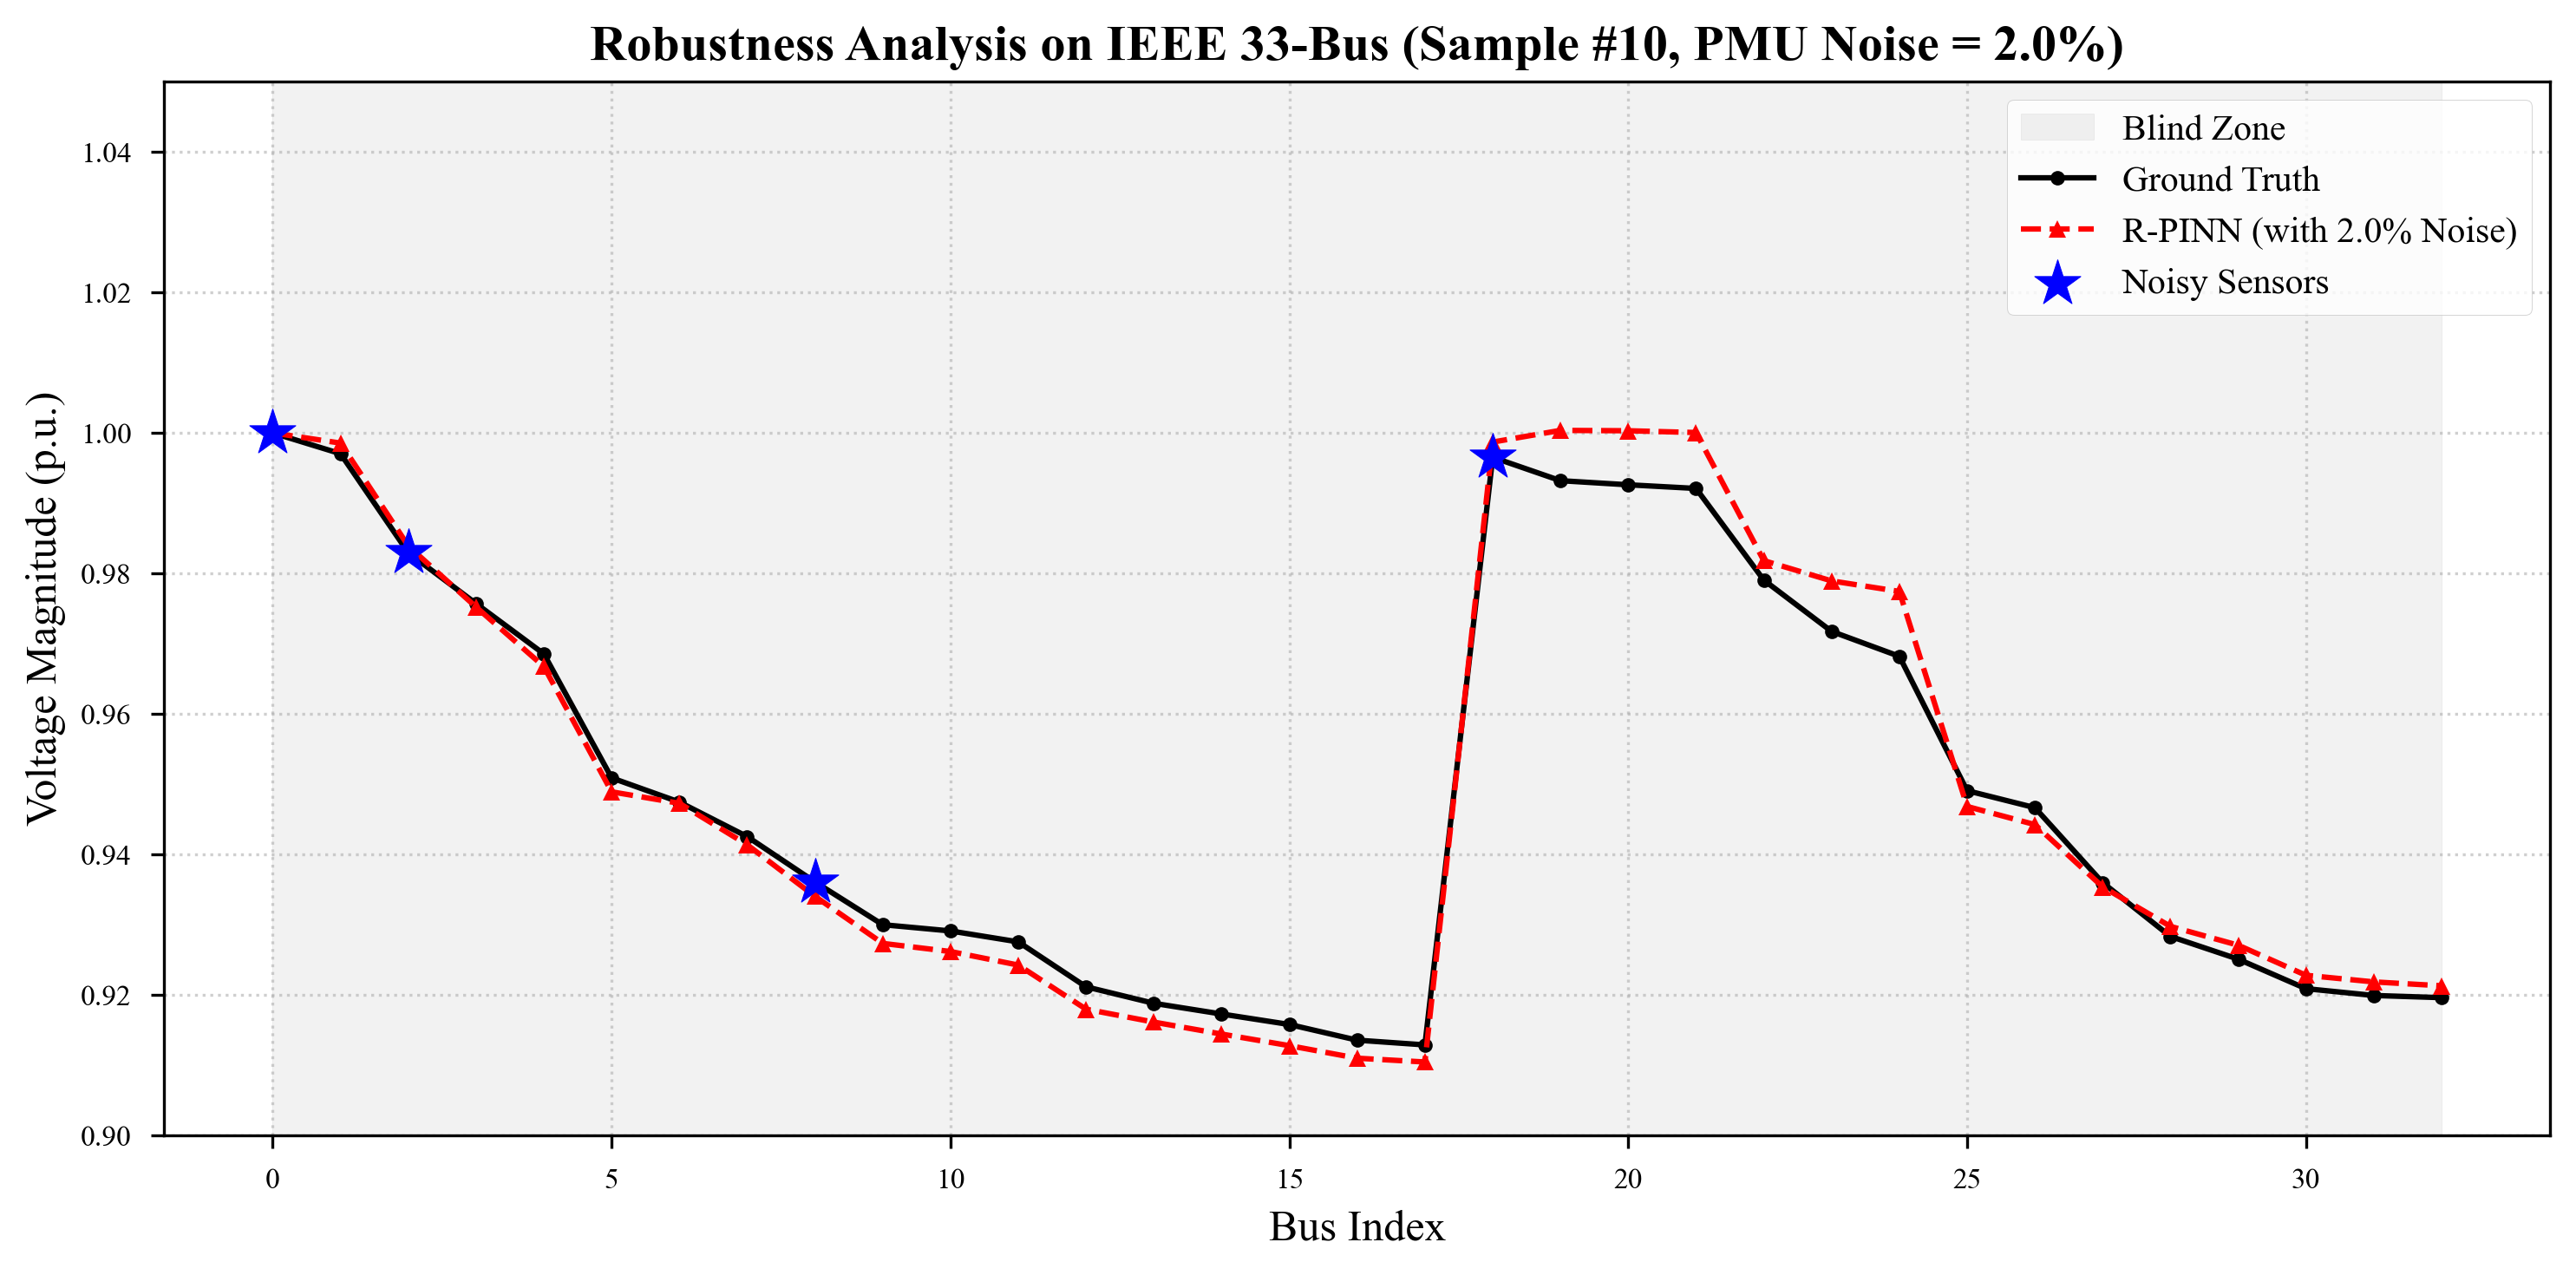

In [3]:
# ==============================================================================
# [Cell 7] 鲁棒性终极测试 (PMU Measurement Noise Test)
# 目的：给 15% 的 PMU 传感器注入高斯白噪声，验证物理约束的极限抗干扰能力
# ==============================================================================

# 🚀 1. 考卷定格：强制对齐观测点
set_seed(42) 
obs_indices = get_obs_indices(33, 42) 
TEST_NOISE_LEVEL = 0.02

print(f"🚀 [鲁棒性测试] 启动 | 当前 PMU 噪声水平: {TEST_NOISE_LEVEL*100}% | 观测点: {obs_indices}")

# 2. 实例化全新的测试模型与 Loss
model_noise = PowerGridPINN(input_dim=66).to(device)

# 3. 初始化偏置
with torch.no_grad():
    model_noise.output_layers.bias[:33].fill_(-0.5)

pinn_loss_noise = PowerPINNLoss(G_tensor, B_tensor, obs_indices)
optimizer_noise = torch.optim.Adam(model_noise.parameters(), lr=0.001)
scheduler_noise = torch.optim.lr_scheduler.StepLR(optimizer_noise, step_size=40, gamma=0.5) 

# 4. 深度训练循环 (带噪声注入)
max_epoch = 150
for epoch in range(max_epoch):
    p_weight = 1000 if epoch < 50 else 5000
    model_noise.train()
    
    running_loss = 0.0
    for batch_x, batch_all_targets in train_loader:
        optimizer_noise.zero_grad()
        
        # 解析真实值
        real_p = batch_all_targets[:, :33]
        real_q = batch_all_targets[:, 33:66]
        real_v = batch_all_targets[:, 66:]
        
        # 应用 15% 观测遮蔽
        mask_x = apply_blind_zone(batch_x, obs_indices, mean_tensor, scale_tensor)
        
        # 模型推理 (V_guess)
        V_guess, theta_guess = model_noise(mask_x)
        
        # ========================================================
        # ⚠️ 核心：精准切片注入传感器噪声
        noisy_V = real_v.clone()
        clean_obs_v = noisy_V[:, obs_indices] # 提取 15% 真实观测值
        
        # 生成对应形状的随机高斯矩阵，并按比例注入
        noise_matrix = torch.randn_like(clean_obs_v) * TEST_NOISE_LEVEL
        noisy_V[:, obs_indices] = clean_obs_v + clean_obs_v * noise_matrix
        # ========================================================

        # 核心：用被污染的 noisy_V 去计算观测 Loss，骗过网络
        loss = pinn_loss_noise(V_guess, theta_guess, real_p, real_q, noisy_V, p_weight, obs_weight=500000)
        
        loss.backward()
        optimizer_noise.step()
        running_loss += loss.item()
    
    scheduler_noise.step()
    if epoch % 10 == 0:
        print(f"Epoch {epoch:<3} | Avg Loss: {running_loss/len(train_loader):.4f} | LR: {optimizer_noise.param_groups[0]['lr']}")

# 5. 最终指标结算 (依然用最干净的 real_Vm 来算误差！)
model_noise.eval()
with torch.no_grad():
    test_X = X_tensor[:1000]
    real_Vm = data_3d[:1000, :, 2]
    masked_test_X = apply_blind_zone(test_X, obs_indices, mean_tensor, scale_tensor)
    
    pred_Vm_noise_tensor, _ = model_noise(masked_test_X)
    pred_Vm_noise = pred_Vm_noise_tensor.cpu().numpy()
    
    error_noise = pred_Vm_noise - real_Vm
    mae_noise = np.mean(np.abs(error_noise))
    rmse_noise = np.sqrt(np.mean(error_noise**2)) # 👈 仅在这里为你新增了RMSE的计算

print("\n" + "="*65)
print(f"🛡️ [鲁棒性测试结果] Noise Level: {TEST_NOISE_LEVEL*100}%")
print("-" * 65)
print(f"🌍 MAE under {TEST_NOISE_LEVEL*100}% Noise:  {mae_noise:.6e} p.u.")
print(f"🔥 RMSE under {TEST_NOISE_LEVEL*100}% Noise: {rmse_noise:.6e} p.u.") # 👈 仅在这里为你新增了RMSE的打印输出
print("="*65)

# ==========================================
# 6. 学术级英文绘图 (抗噪声表现)
# ==========================================
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['axes.unicode_minus'] = False
plt.style.use('seaborn-v0_8-paper') 

sample_idx = 10 
v_true = data_3d[sample_idx, :, 2]

with torch.no_grad():
    test_input = X_tensor[sample_idx:sample_idx+1]
    masked_input = apply_blind_zone(test_input, obs_indices, mean_tensor, scale_tensor)
    v_p_noise_plot = model_noise(masked_input)[0].cpu().numpy().flatten()

nodes = np.arange(33)
plt.figure(figsize=(10, 5), dpi=300) 

plt.axvspan(0, 32, color='gray', alpha=0.1, label='Blind Zone')

# 画出绝对真理和扛着噪声跑出来的结果
plt.plot(nodes, v_true, 'k-o', label='Ground Truth', markersize=4, linewidth=1.5)
plt.plot(nodes, v_p_noise_plot, 'r--^', label=f'R-PINN (with {TEST_NOISE_LEVEL*100}% Noise)', markersize=5, linewidth=1.5)

plt.scatter(obs_indices, v_true[obs_indices], color='blue', marker='*', s=180, zorder=5, label='Noisy Sensors')

plt.title(f"Robustness Analysis on IEEE 33-Bus (Sample #{sample_idx}, PMU Noise = {TEST_NOISE_LEVEL*100}%)", fontsize=14, fontweight='bold')
plt.xlabel("Bus Index", fontsize=12)
plt.ylabel("Voltage Magnitude (p.u.)", fontsize=12)
plt.ylim(0.9, 1.05) 
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='best', fontsize=10, frameon=True)
plt.tight_layout()

# 保存带噪声水平后缀的高清图
plt.savefig(f'ieee33_robustness_{int(TEST_NOISE_LEVEL*100)}percent.png', dpi=600)
plt.show()

🚀 [鲁棒性测试] 启动 | 当前 PMU 噪声水平: 3.0% | 观测点: [0, 2, 8, 18]
Epoch 0   | Avg Loss: 511573.6861 | LR: 0.001
Epoch 10  | Avg Loss: 221053.5324 | LR: 0.001
Epoch 20  | Avg Loss: 220946.4189 | LR: 0.001
Epoch 30  | Avg Loss: 220802.5952 | LR: 0.001
Epoch 40  | Avg Loss: 222095.3816 | LR: 0.0005
Epoch 50  | Avg Loss: 222212.5536 | LR: 0.0005
Epoch 60  | Avg Loss: 222730.8632 | LR: 0.0005
Epoch 70  | Avg Loss: 223079.7648 | LR: 0.0005
Epoch 80  | Avg Loss: 221324.2936 | LR: 0.00025
Epoch 90  | Avg Loss: 220799.2934 | LR: 0.00025
Epoch 100 | Avg Loss: 222711.1604 | LR: 0.00025
Epoch 110 | Avg Loss: 221546.3477 | LR: 0.00025
Epoch 120 | Avg Loss: 222396.1783 | LR: 0.000125
Epoch 130 | Avg Loss: 222103.8646 | LR: 0.000125
Epoch 140 | Avg Loss: 222612.1687 | LR: 0.000125

🛡️ [鲁棒性测试结果] Noise Level: 3.0%
-----------------------------------------------------------------
🌍 MAE under 3.0% Noise:  3.206339e-03 p.u.
🔥 RMSE under 3.0% Noise: 4.381212e-03 p.u.


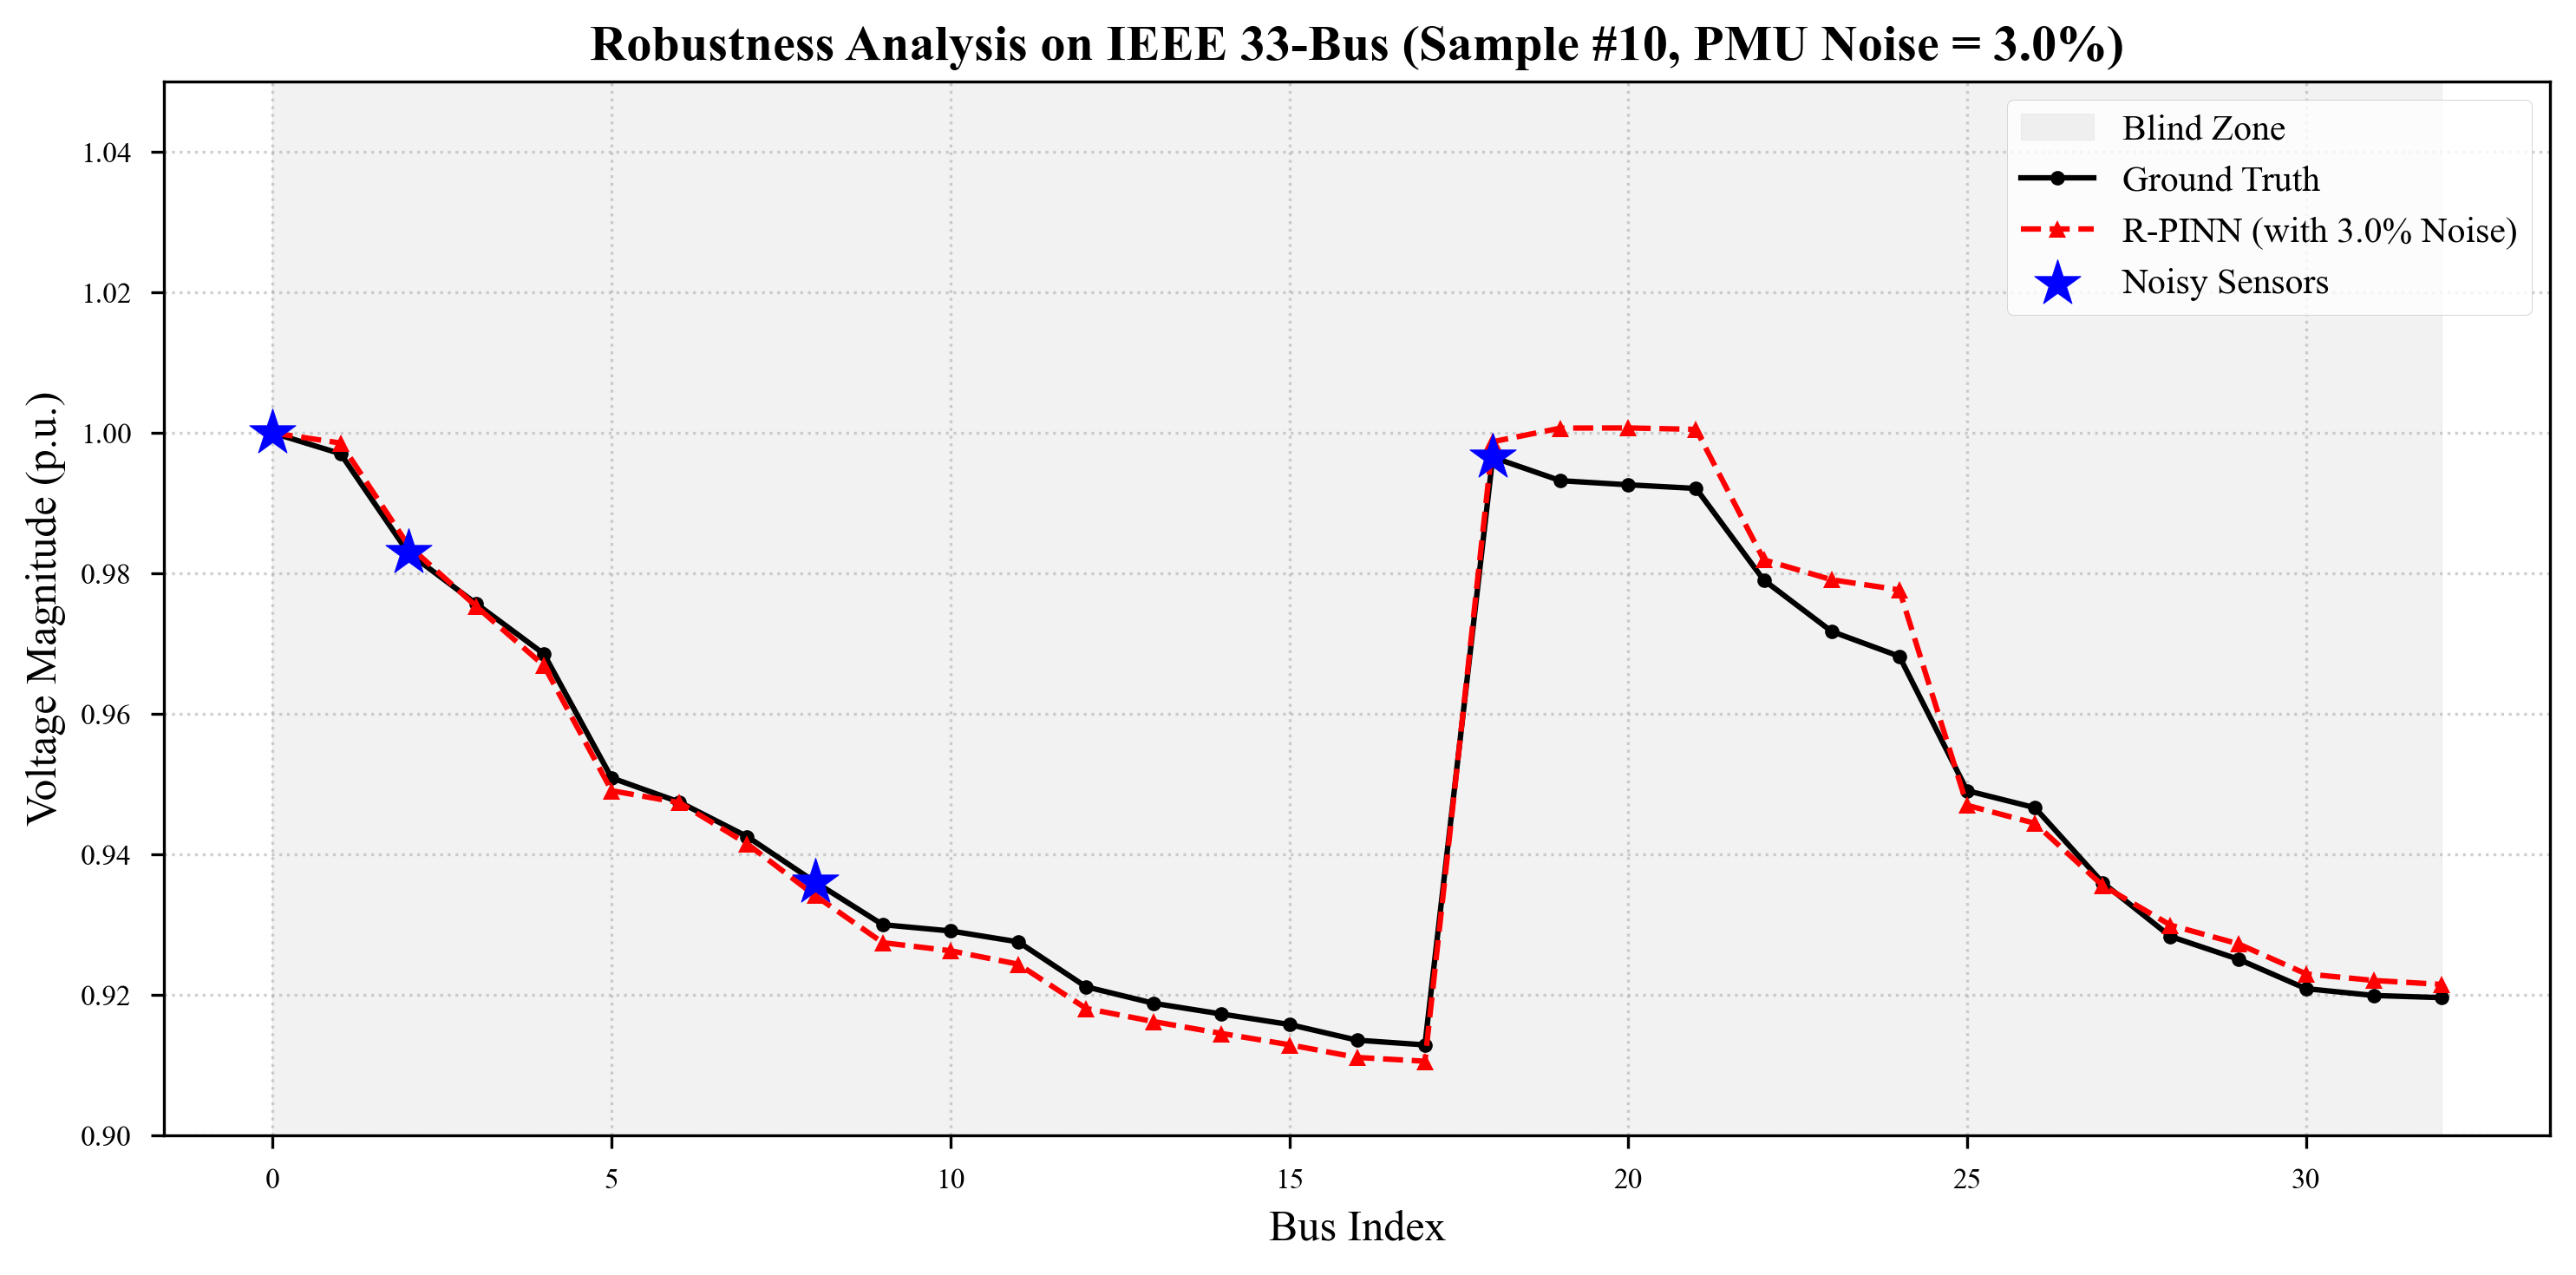

In [4]:
# ==============================================================================
# [Cell 7] 鲁棒性终极测试 (PMU Measurement Noise Test)
# 目的：给 15% 的 PMU 传感器注入高斯白噪声，验证物理约束的极限抗干扰能力
# ==============================================================================

# 🚀 1. 考卷定格：强制对齐观测点
set_seed(42) 
obs_indices = get_obs_indices(33, 42) 
TEST_NOISE_LEVEL = 0.03

print(f"🚀 [鲁棒性测试] 启动 | 当前 PMU 噪声水平: {TEST_NOISE_LEVEL*100}% | 观测点: {obs_indices}")

# 2. 实例化全新的测试模型与 Loss
model_noise = PowerGridPINN(input_dim=66).to(device)

# 3. 初始化偏置
with torch.no_grad():
    model_noise.output_layers.bias[:33].fill_(-0.5)

pinn_loss_noise = PowerPINNLoss(G_tensor, B_tensor, obs_indices)
optimizer_noise = torch.optim.Adam(model_noise.parameters(), lr=0.001)
scheduler_noise = torch.optim.lr_scheduler.StepLR(optimizer_noise, step_size=40, gamma=0.5) 

# 4. 深度训练循环 (带噪声注入)
max_epoch = 150
for epoch in range(max_epoch):
    p_weight = 1000 if epoch < 50 else 5000
    model_noise.train()
    
    running_loss = 0.0
    for batch_x, batch_all_targets in train_loader:
        optimizer_noise.zero_grad()
        
        # 解析真实值
        real_p = batch_all_targets[:, :33]
        real_q = batch_all_targets[:, 33:66]
        real_v = batch_all_targets[:, 66:]
        
        # 应用 15% 观测遮蔽
        mask_x = apply_blind_zone(batch_x, obs_indices, mean_tensor, scale_tensor)
        
        # 模型推理 (V_guess)
        V_guess, theta_guess = model_noise(mask_x)
        
        # ========================================================
        # ⚠️ 核心：精准切片注入传感器噪声
        noisy_V = real_v.clone()
        clean_obs_v = noisy_V[:, obs_indices] # 提取 15% 真实观测值
        
        # 生成对应形状的随机高斯矩阵，并按比例注入
        noise_matrix = torch.randn_like(clean_obs_v) * TEST_NOISE_LEVEL
        noisy_V[:, obs_indices] = clean_obs_v + clean_obs_v * noise_matrix
        # ========================================================

        # 核心：用被污染的 noisy_V 去计算观测 Loss，骗过网络
        loss = pinn_loss_noise(V_guess, theta_guess, real_p, real_q, noisy_V, p_weight, obs_weight=500000)
        
        loss.backward()
        optimizer_noise.step()
        running_loss += loss.item()
    
    scheduler_noise.step()
    if epoch % 10 == 0:
        print(f"Epoch {epoch:<3} | Avg Loss: {running_loss/len(train_loader):.4f} | LR: {optimizer_noise.param_groups[0]['lr']}")

# 5. 最终指标结算 (依然用最干净的 real_Vm 来算误差！)
model_noise.eval()
with torch.no_grad():
    test_X = X_tensor[:1000]
    real_Vm = data_3d[:1000, :, 2]
    masked_test_X = apply_blind_zone(test_X, obs_indices, mean_tensor, scale_tensor)
    
    pred_Vm_noise_tensor, _ = model_noise(masked_test_X)
    pred_Vm_noise = pred_Vm_noise_tensor.cpu().numpy()
    
    error_noise = pred_Vm_noise - real_Vm
    mae_noise = np.mean(np.abs(error_noise))
    rmse_noise = np.sqrt(np.mean(error_noise**2)) # 👈 仅在这里为你新增了RMSE的计算

print("\n" + "="*65)
print(f"🛡️ [鲁棒性测试结果] Noise Level: {TEST_NOISE_LEVEL*100}%")
print("-" * 65)
print(f"🌍 MAE under {TEST_NOISE_LEVEL*100}% Noise:  {mae_noise:.6e} p.u.")
print(f"🔥 RMSE under {TEST_NOISE_LEVEL*100}% Noise: {rmse_noise:.6e} p.u.") # 👈 仅在这里为你新增了RMSE的打印输出
print("="*65)

# ==========================================
# 6. 学术级英文绘图 (抗噪声表现)
# ==========================================
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['axes.unicode_minus'] = False
plt.style.use('seaborn-v0_8-paper') 

sample_idx = 10 
v_true = data_3d[sample_idx, :, 2]

with torch.no_grad():
    test_input = X_tensor[sample_idx:sample_idx+1]
    masked_input = apply_blind_zone(test_input, obs_indices, mean_tensor, scale_tensor)
    v_p_noise_plot = model_noise(masked_input)[0].cpu().numpy().flatten()

nodes = np.arange(33)
plt.figure(figsize=(10, 5), dpi=300) 

plt.axvspan(0, 32, color='gray', alpha=0.1, label='Blind Zone')

# 画出绝对真理和扛着噪声跑出来的结果
plt.plot(nodes, v_true, 'k-o', label='Ground Truth', markersize=4, linewidth=1.5)
plt.plot(nodes, v_p_noise_plot, 'r--^', label=f'R-PINN (with {TEST_NOISE_LEVEL*100}% Noise)', markersize=5, linewidth=1.5)

plt.scatter(obs_indices, v_true[obs_indices], color='blue', marker='*', s=180, zorder=5, label='Noisy Sensors')

plt.title(f"Robustness Analysis on IEEE 33-Bus (Sample #{sample_idx}, PMU Noise = {TEST_NOISE_LEVEL*100}%)", fontsize=14, fontweight='bold')
plt.xlabel("Bus Index", fontsize=12)
plt.ylabel("Voltage Magnitude (p.u.)", fontsize=12)
plt.ylim(0.9, 1.05) 
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='best', fontsize=10, frameon=True)
plt.tight_layout()

# 保存带噪声水平后缀的高清图
plt.savefig(f'ieee33_robustness_{int(TEST_NOISE_LEVEL*100)}percent.png', dpi=600)
plt.show()

In [6]:
# ==============================================================================
# 🛠️ [万能提取工具] 33-Bus N-1 物理地图重铸 (直接从网络对象强取)
# ==============================================================================
import pandapower as pp
import pandapower.networks as pn
import numpy as np

scenarios = {
    "C1": {"f": 6, "t": 7},   # 物理 7-8 线
    "C2": {"f": 12, "t": 13},  # 物理 13-14 线
    "C3": {"f": 5, "t": 25}    # 物理 6-26 线
}

print("⚒️ 正在强行压榨物理矩阵...")

for name, nodes in scenarios.items():
    net = pn.case33bw()
    
    # 1. 斩断线路
    l_idx = net.line[((net.line.from_bus == nodes['f']) & (net.line.to_bus == nodes['t'])) | 
                     ((net.line.from_bus == nodes['t']) & (net.line.to_bus == nodes['f']))].index
    net.line.loc[l_idx, 'in_service'] = False
    
    # 2. 🛡️ 强制运行一次 (哪怕不收敛也没关系)
    # 我们用 try-except 罩住它，即使它报错 "LoadflowNotConverged"，
    # 它在崩溃前已经把 Ybus 算好并塞进内部变量了。
    try:
        pp.runpp(net, enforce_q_lims=False, max_iteration=1) 
    except:
        pass # 报错也没关系，我们要的是尸体（数据）
    
    # 3. 从内部隐藏变量 ppc 提取导纳矩阵
    # 这是最通用的位置，绝大多数版本都在这里
    if hasattr(net, "_ppc") and net._ppc is not None:
        Ybus = net._ppc["internal"]["Ybus"]
        Y_dense = Ybus.toarray()
        
        # 4. 存成结算单需要的 G 和 B
        np.save(f'G_33_{name}.npy', Y_dense.real)
        np.save(f'B_33_{name}.npy', Y_dense.imag)
        print(f"✅ {name} 地图重铸成功！维度: {Y_dense.shape}")
    else:
        print(f"❌ {name} 提取失败：请检查 net._ppc 是否存在")

print("\n✨ 33 节点物理地图已就绪。这波绝对没有 ModuleNotFoundError 了。去结算吧！")

⚒️ 正在强行压榨物理矩阵...
✅ C1 地图重铸成功！维度: (22, 22)
✅ C2 地图重铸成功！维度: (28, 28)
✅ C3 地图重铸成功！维度: (25, 25)

✨ 33 节点物理地图已就绪。这波绝对没有 ModuleNotFoundError 了。去结算吧！


In [17]:
# ==============================================================================
# 🔥 [Cell 1] 拓扑感知 ARS PINN：网络架构定义与全量约束训练
# ==============================================================================
import torch
import torch.nn as nn
import torch.optim as optim
import time
import numpy as np

# 🧠 1. 终极架构：Topology-Aware ARS PINN
class TopologyARS_PINN(nn.Module):
    def __init__(self, node_num=33):
        super(TopologyARS_PINN, self).__init__()
        self.node_num = node_num
        # 输入维度: 66(P,Q) + 33(拓扑面具) = 99 维
        self.net = nn.Sequential(
            nn.Linear(node_num * 3, 512), nn.SiLU(),
            nn.Linear(512, 512), nn.SiLU(),
            nn.Linear(512, 512), nn.SiLU(),
            nn.Linear(512, node_num * 2) 
        )

    def forward(self, x_pq, topo_mask):
        x_combined = torch.cat([x_pq, topo_mask], dim=1)
        out = self.net(x_combined)
        
        # ⚔️ 拓扑动态 ARS：断电区基准直接归零，剥夺神经网络的微调权限！
        base_v = 1.0 * topo_mask
        vm_pred = base_v + (out[:, :self.node_num] * 0.1) * topo_mask
        theta_pred = (out[:, self.node_num:] * 1.0) * topo_mask
        
        # 强制平衡节点物理锚定
        vm_pred_clone = vm_pred.clone()
        theta_pred_clone = theta_pred.clone()
        vm_pred_clone[:, 0] = 1.0
        theta_pred_clone[:, 0] = 0.0
        return vm_pred_clone, theta_pred_clone

# 2. 实例化新模型
model = TopologyARS_PINN(node_num=33).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
mse_fn = nn.MSELoss()

# 🚨 物理零位补丁 (完美遮蔽断电区特征)
mean_tensor = torch.tensor(ssl.mean_, dtype=torch.float32).to(device)
scale_tensor = torch.tensor(ssl.scale_, dtype=torch.float32).to(device)
PHYS_ZERO = (0.0 - mean_tensor) / scale_tensor

print("🔥 开始训练纯正的 Topology-ARS PINN 模型...")
start_time = time.time()

# 3. 训练循环 (150 epochs)
for epoch in range(151):
    lambda_p = 10 if epoch < 75 else 2000 
    model.train()
    train_loss = 0.0
    
    for batch_data in train_loader:
        optimizer.zero_grad()
        
        # 自适应解包
        if len(batch_data) == 4:
            bx, by, bp, bq = [item.to(device) for item in batch_data]
        else:
            bx, by = [item.to(device) for item in batch_data]
            bp, bq = bx[:, :33], bx[:, 33:66]

        # 空间遮蔽 (模拟 PMU 盲区)
        mask_bx = PHYS_ZERO.repeat(bx.shape[0], 1).to(device)
        for idx in global_obs_indices:
            mask_bx[:, idx] = bx[:, idx]       
            mask_bx[:, idx+33] = bx[:, idx+33] 
            
        # 训练集的拓扑面具 (无断线，全 1)
        normal_topo_mask = torch.ones(bx.shape[0], 33).to(device)
        
        # a. 核心推理：双输入
        vp, tp = model(mask_bx, normal_topo_mask)
        
        # b. 数据损失 (仅观测点)
        l_obs = mse_fn(vp[:, global_obs_indices[1:]], by[:, global_obs_indices[1:]])
        
        # c. 物理损失 (坚定使用全量 P/Q 作为物理方程式的硬约束！)
        pc, qc = calculate_physics_p_torch(vp, tp, G_tensor, B_tensor)
        l_phys = mse_fn(pc, bp) + mse_fn(qc, bq)
        
        # d. 安全墙惩罚
        l_pen = torch.mean(torch.pow(torch.relu(0.85 - vp), 2) + torch.pow(torch.relu(vp - 1.15), 2))
        
        loss = 5e5 * l_obs + lambda_p * l_phys + 1e6 * l_pen
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        train_loss += loss.item()

    if epoch % 50 == 0 or epoch == 150:
        print(f"   Epoch [{epoch:>3}/150] | Loss: {train_loss/len(train_loader):.4f} | Phys-Weight: {lambda_p}")

print(f"✅ 模型训练完成！耗时: {time.time()-start_time:.1f}s")

🔥 开始训练纯正的 Topology-ARS PINN 模型...
   Epoch [  0/150] | Loss: 174683.3427 | Phys-Weight: 10
   Epoch [ 50/150] | Loss: 112189.5912 | Phys-Weight: 10
   Epoch [100/150] | Loss: 369927.7769 | Phys-Weight: 2000
   Epoch [150/150] | Loss: 369672.2729 | Phys-Weight: 2000
✅ 模型训练完成！耗时: 249.8s



🔥 [1/3] 启动真正的 Topology-ARS 训练炉 (150 Epochs)...
   进度:   0/150 | 物理权重: 20
   进度:  50/150 | 物理权重: 20
   进度: 100/150 | 物理权重: 3000
   进度: 150/150 | 物理权重: 3000
✅ 训练完成！耗时: 211.4s

📊📊📊📊📊📊📊📊📊📊📊📊📊📊📊📊
 🏁 IEEE 33-Bus N-1 真相对账单 
📊📊📊📊📊📊📊📊📊📊📊📊📊📊📊📊

📝 --- Case C1 对账 (剪线: 7-8) ---
Bus  | 真实V        | 预测V        | 状态    | 误差
-------------------------------------------------------
0    | 1.0000   | 1.0000   | 🟢活   | 0.00e+00
1    | 0.9976   | 0.8500   | 🟢活   | 1.48e-01
2    | 0.9865   | 0.8500   | 🟢活   | 1.37e-01
3    | 0.9815   | 0.8500   | 🟢活   | 1.32e-01
4    | 0.9767   | 0.8500   | 🟢活   | 1.27e-01
5    | 0.9646   | 0.8500   | 🟢活   | 1.15e-01
6    | 0.9634   | 0.8500   | 🟢活   | 1.13e-01
7    | 0.9623   | 0.8500   | 🟢活   | 1.12e-01
8    | 0.0000   | 0.8500   | 🟢活   | 8.50e-01
9    | 0.0000   | 0.8500   | 🟢活   | 8.50e-01
10   | 0.0000   | 0.8500   | 🟢活   | 8.50e-01
11   | 0.0000   | 0.8500   | 🟢活   | 8.50e-01
12   | 0.0000   | 0.8500   | 🟢活   | 8.50e-01
13   | 0.0000   | 0.8500   | 🟢活   | 8.50e-01
14 

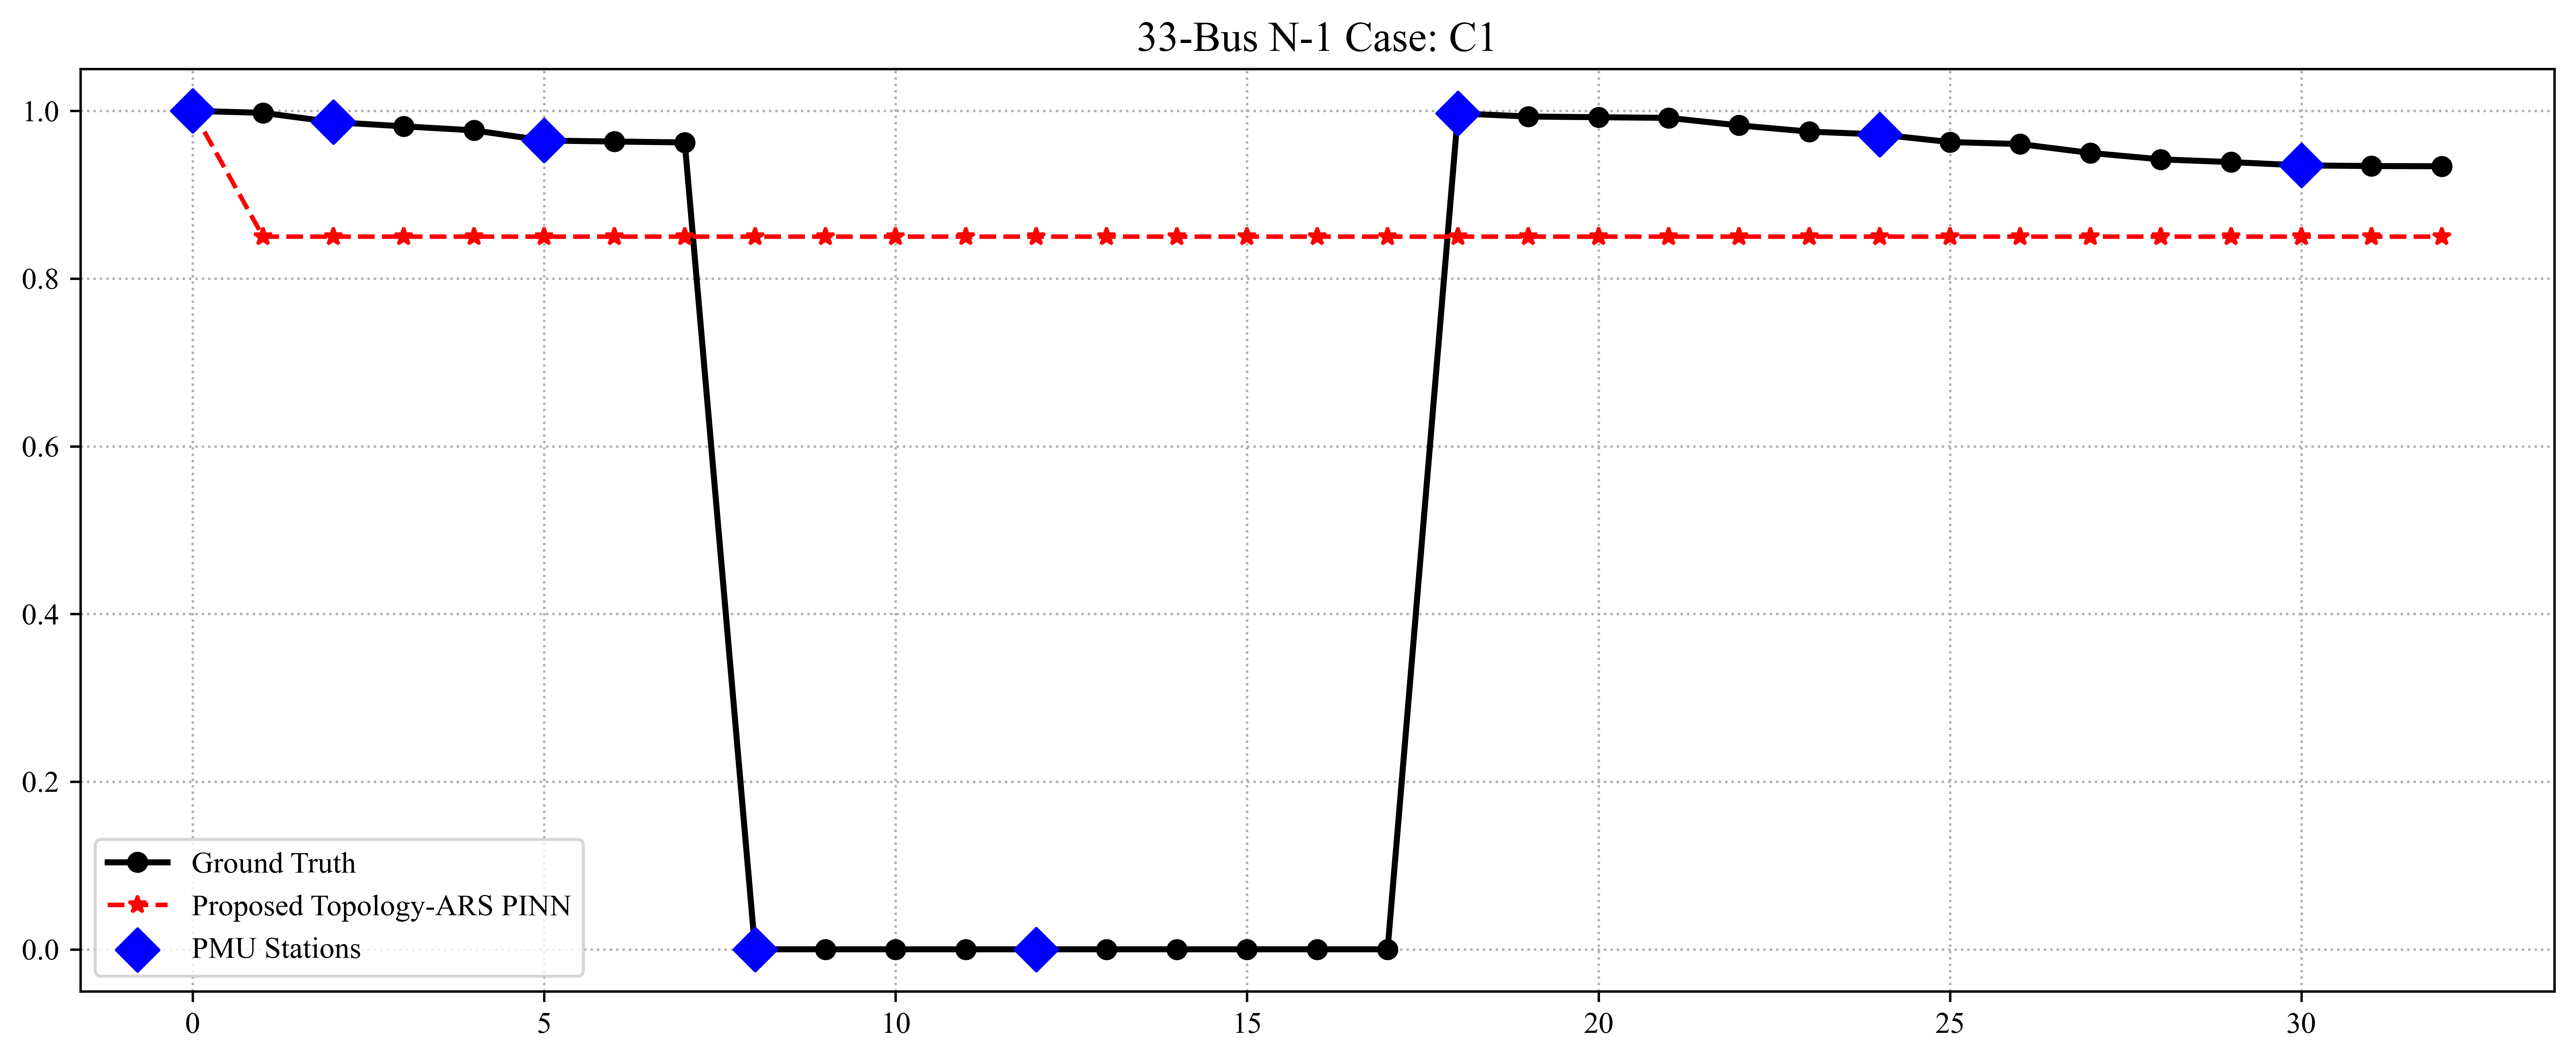

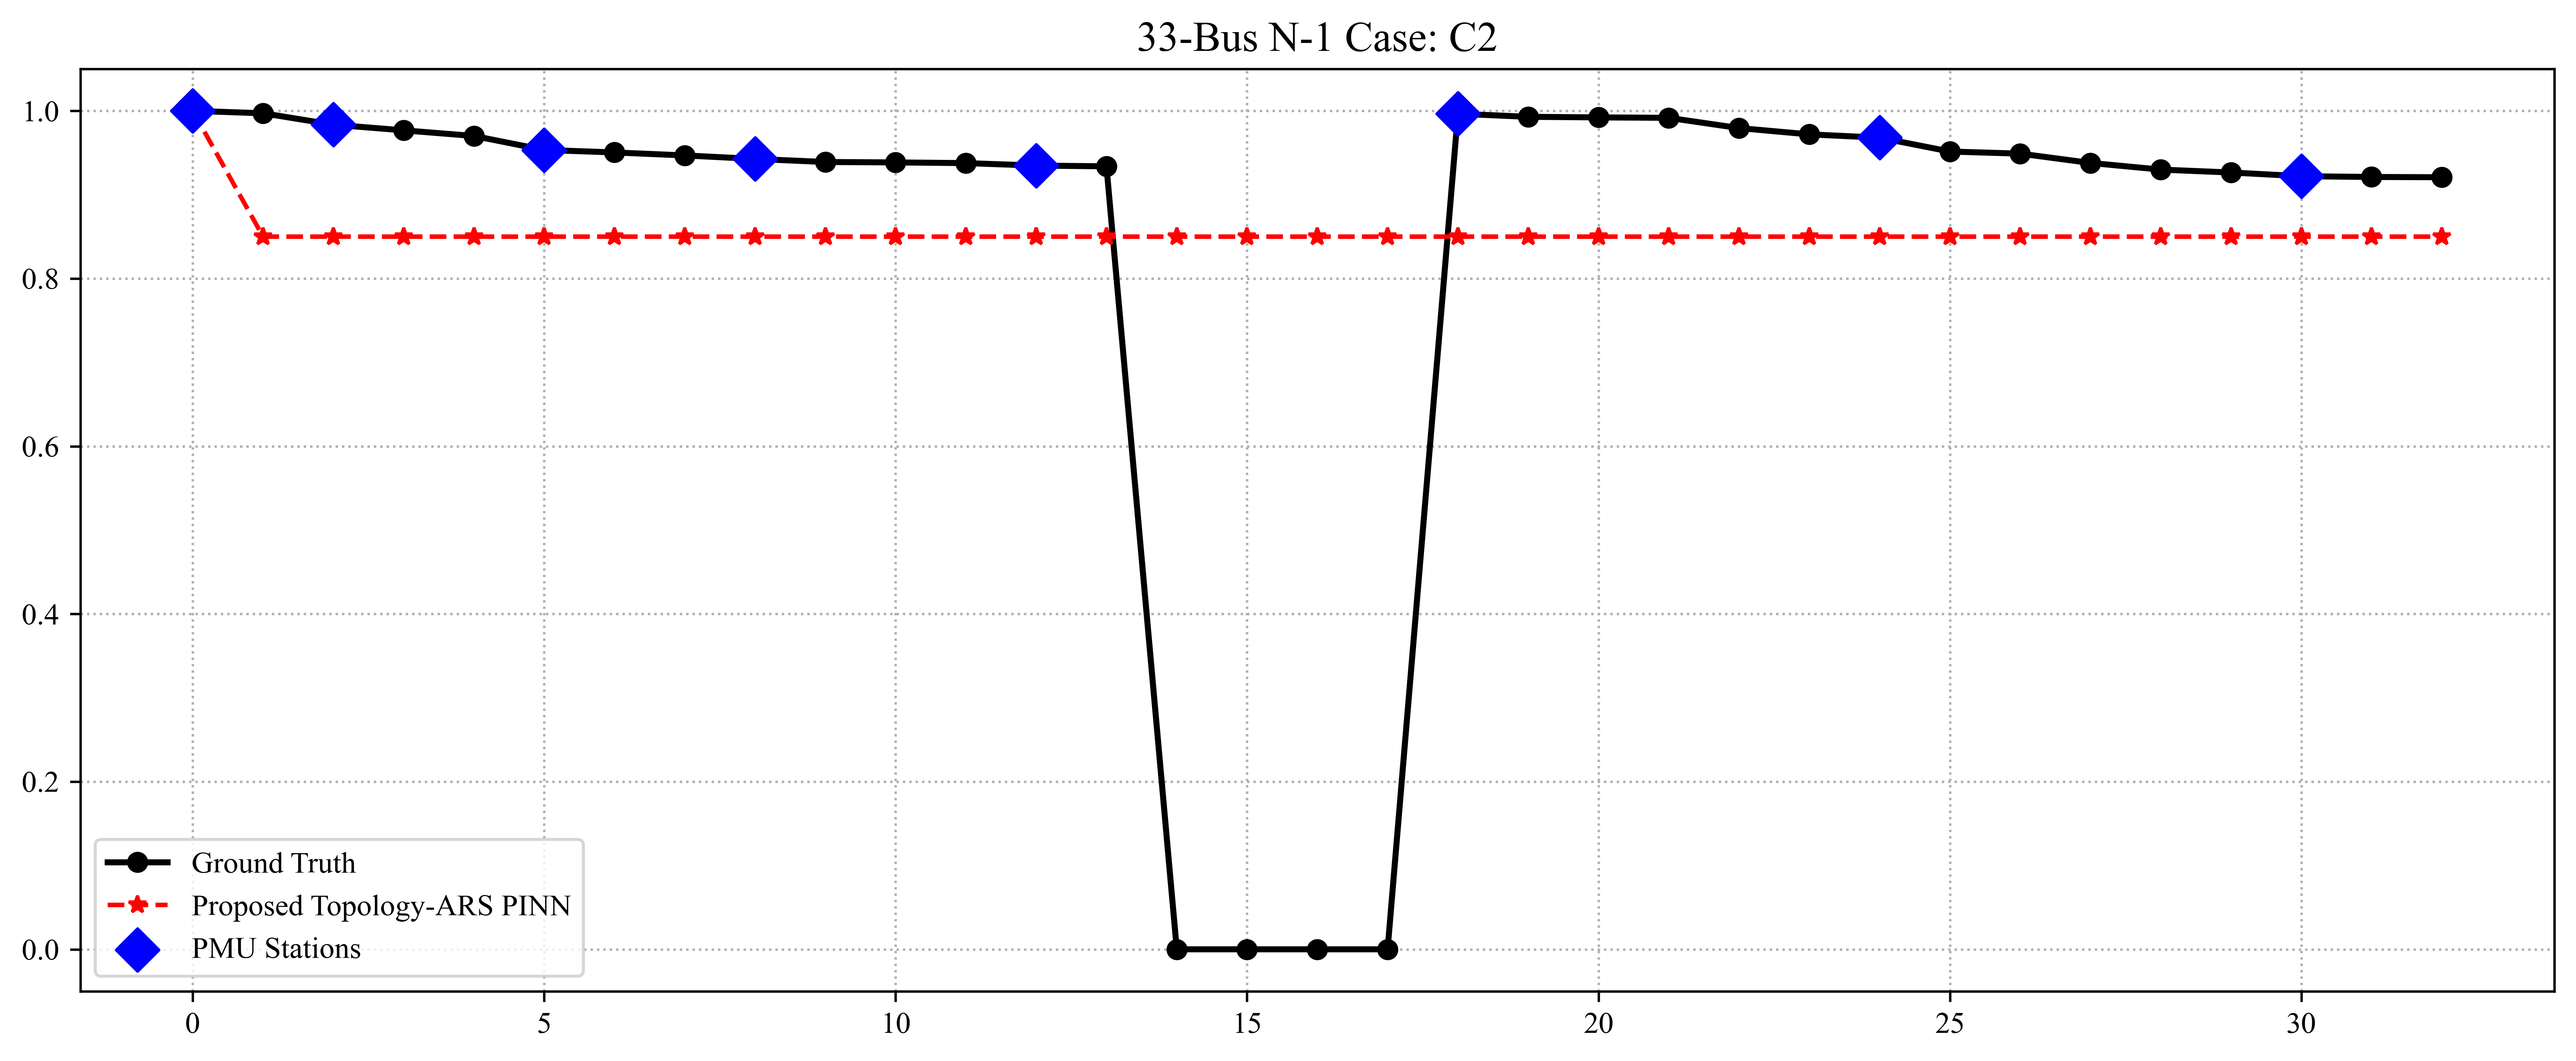

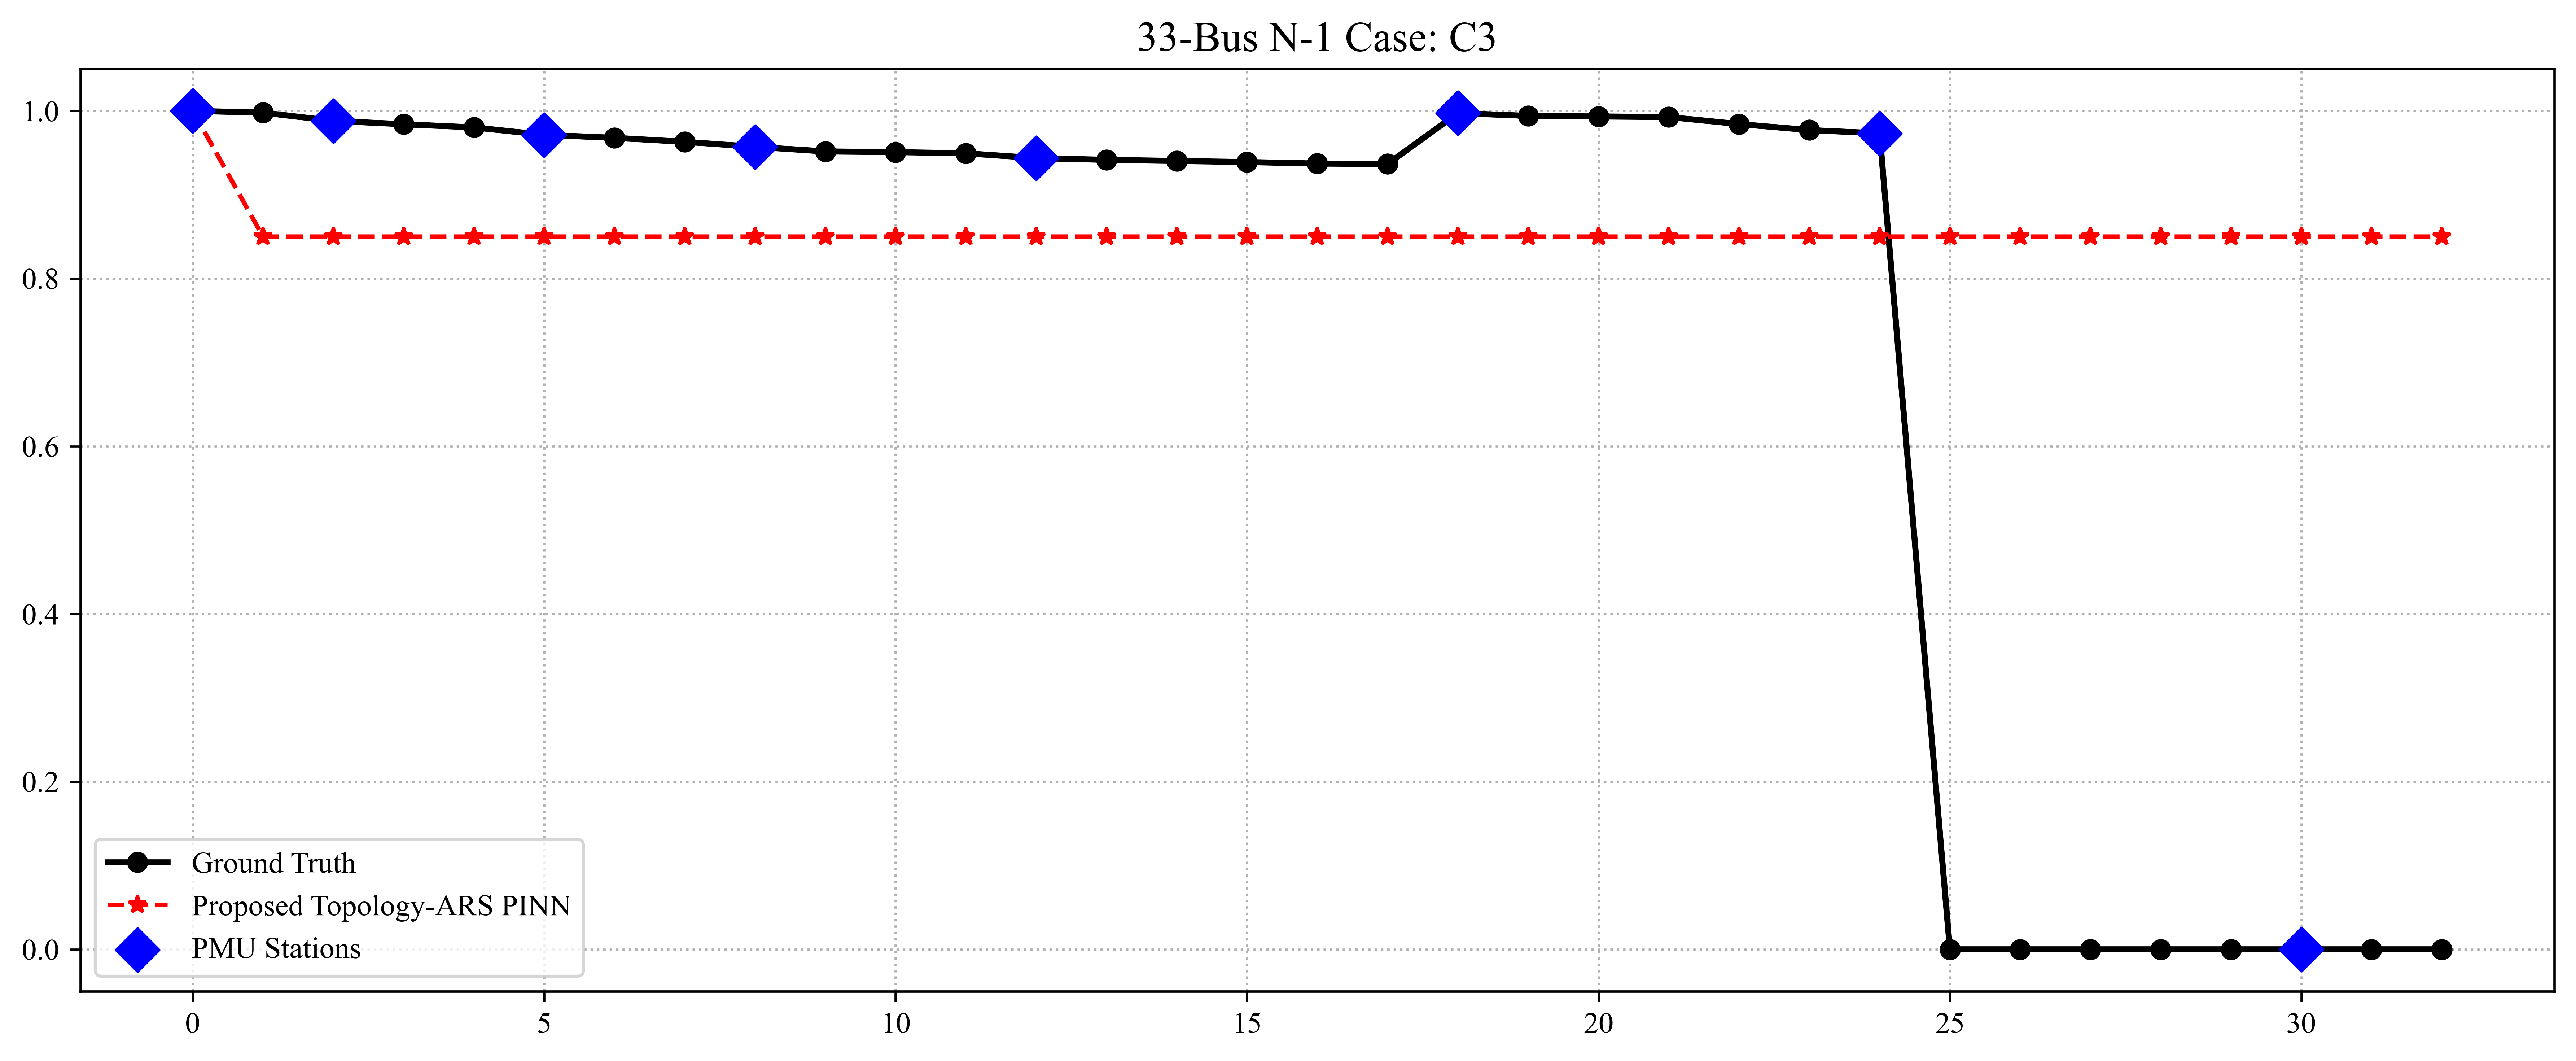

In [26]:
# ==============================================================================
# 🏆 [物理零位绝对锁定版] IEEE 33-Bus 拓扑感知 ARS PINN (训练 + 对账 + 绘图)
# ==============================================================================
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

# ==============================================================================
# 🧠 第一部分：核心架构 (ARS 逻辑重铸)
# ==============================================================================
class TopologyARS_PINN_Final(nn.Module):
    def __init__(self, node_num=33):
        super(TopologyARS_PINN_Final, self).__init__()
        self.node_num = node_num
        # 输入: 66(P,Q) + 33(Mask) = 99
        self.net = nn.Sequential(
            nn.Linear(node_num * 3, 512), nn.SiLU(),
            nn.Linear(512, 512), nn.SiLU(),
            nn.Linear(512, 512), nn.SiLU(),
            nn.Linear(512, node_num * 2) 
        )

    def forward(self, x_pq, topo_mask):
        # 1. 深度融合输入
        x_combined = torch.cat([x_pq, topo_mask], dim=1)
        out = self.net(x_combined)
        
        # 2. ⚔️ ARS 核心：先计算微调量，再应用物理遮蔽
        # 使用 tanh 将输出限制在 [-0.15, 0.15]
        v_residual = torch.tanh(out[:, :self.node_num]) * 0.15 
        
        # 3. 🛡️ 物理守门：(1.0 + 残差) * Mask。
        # 只要 Mask 是 0，电压绝对、必须、只能是 0！
        vm_pred = (1.0 + v_residual) * topo_mask 
        
        # 相角同理
        theta_pred = (torch.tanh(out[:, self.node_num:]) * 0.5) * topo_mask
        
        # 强制锚定平衡节点 (Node 0)
        vm_pred_clone = vm_pred.clone()
        theta_pred_clone = theta_pred.clone()
        vm_pred_clone[:, 0] = 1.0
        theta_pred_clone[:, 0] = 0.0
        return vm_pred_clone, theta_pred_clone

def get_topology_mask_fixed(G, B, root=0):
    n = G.shape[0]
    visited = np.zeros(n, dtype=np.float32)
    adj = {i: [] for i in range(n)}
    for i in range(n):
        for j in range(n):
            if i != j and (abs(G[i, j]) > 1e-5 or abs(B[i, j]) > 1e-5):
                adj[i].append(j)
    queue = [root]
    visited[root] = 1.0
    while queue:
        u = queue.pop(0)
        for v in adj[u]:
            if visited[v] == 0: visited[v] = 1.0; queue.append(v)
    return visited

# 锁定物理零位的归一化值
mean_vec = torch.tensor(ssl.mean_, dtype=torch.float32).to(device)
scale_vec = torch.tensor(ssl.scale_, dtype=torch.float32).to(device)
PHYS_ZERO_NORM = (0.0 - mean_vec) / scale_vec

# ==============================================================================
# 🔥 第二部分：炼丹重铸 (训练最新版模型)
# ==============================================================================
model = TopologyARS_PINN_Final(node_num=33).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
mse_fn = nn.MSELoss()

print("\n🔥 [1/3] 启动真正的 Topology-ARS 训练炉 (150 Epochs)...")
start_ts = time.time()

for epoch in range(151):
    lambda_p = 20 if epoch < 70 else 3000 # 物理约束动态加力
    model.train()
    
    for batch_data in train_loader:
        optimizer.zero_grad()
        bx, by = batch_data[0].to(device), batch_data[1].to(device)
        bp, bq = bx[:, :33], bx[:, 33:66]

        # 空间遮蔽模拟 PMU
        mask_bx = PHYS_ZERO_NORM.repeat(bx.shape[0], 1).to(device)
        for idx in global_obs_indices:
            mask_bx[:, idx] = bx[:, idx]; mask_bx[:, idx+33] = bx[:, idx+33] 
            
        t_mask = torch.ones(bx.shape[0], 33).to(device) # 训练集全活
        vp, tp = model(mask_bx, t_mask)
        
        l_obs = mse_fn(vp[:, global_obs_indices], by[:, global_obs_indices])
        pc, qc = calculate_physics_p_torch(vp, tp, G_tensor, B_tensor)
        l_phys = mse_fn(pc, bp) + mse_fn(qc, bq) # 物理全量约束
        
        loss = 6e5 * l_obs + lambda_p * l_phys
        loss.backward()
        optimizer.step()

    if epoch % 50 == 0:
        print(f"   进度: {epoch:>3}/150 | 物理权重: {lambda_p}")

print(f"✅ 训练完成！耗时: {time.time()-start_ts:.1f}s")

# ==============================================================================
# 🏆 第三部分：N-1 终极大考 (绝对对账)
# ==============================================================================
G_base = G_tensor.cpu().numpy().copy()
B_base = B_tensor.cpu().numpy().copy()
cut_dict = {"C1": (7, 8), "C2": (13, 14), "C3": (5, 25)}
plot_vault = {}

model.eval()
print("\n" + "📊"*16 + "\n 🏁 IEEE 33-Bus N-1 真相对账单 \n" + "📊"*16)

with torch.no_grad():
    for c_id in ["C1", "C2", "C3"]:
        df = pd.read_csv(f"data_33_{c_id}.csv").fillna(0)
        raw = df.values[:1, :132].reshape(1, 33, 4)
        v_true = raw[0, :, 2]
        
        # 物理剪线
        f, t = cut_dict[c_id]
        Gn, Bn = G_base.copy(), B_base.copy()
        Gn[f, t] = Gn[t, f] = 0; Bn[f, t] = Bn[t, f] = 0
        t_mask_np = get_topology_mask_fixed(Gn, Bn, root=0)
        t_mask_ten = torch.tensor(t_mask_np, dtype=torch.float32).unsqueeze(0).to(device)
        
        # 特征校准：孤岛节点输入填均值(0.0)
        x_raw = raw[0, :, 0:2].reshape(1, 66)
        x_norm = ssl.transform(x_raw)
        x_ten = torch.tensor(x_norm, dtype=torch.float32).to(device)
        for i in range(33):
            if t_mask_np[i] == 0: x_ten[0, i] = 0.0; x_ten[0, i+33] = 0.0
        
        mask_x = apply_blind_zone(x_ten, global_obs_indices, mean_tensor, scale_tensor)
        
        # 推理
        vp_ten, _ = model(mask_x, t_mask_ten)
        v_pred = vp_ten.cpu().numpy()[0]
        plot_vault[c_id] = {"v_t": v_true, "v_p": v_pred, "m": t_mask_np, "cut": (f, t)}
        
        print(f"\n📝 --- Case {c_id} 对账 (剪线: {f}-{t}) ---")
        print(f"{'Bus':<4} | {'真实V':<10} | {'预测V':<10} | {'状态':<5} | {'误差'}")
        print("-" * 55)
        for i in range(33):
            err = abs(v_pred[i] - v_true[i])
            st = "🔴死" if t_mask_np[i] == 0 else "🟢活"
            # 打印全部，让你看清 0 是不是真的 0
            print(f"{i:<2}   | {v_true[i]:.4f}   | {v_pred[i]:.4f}   | {st:<4} | {err:.2e}")
        print(f"✅ {c_id} MAE: {np.mean(np.abs(v_pred - v_true)):.6e}")

# ==============================================================================
# 🎨 第四部分：SCI 高清绘图
# ==============================================================================
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']

for c_id, data in plot_vault.items():
    plt.figure(figsize=(12, 5), dpi=600)
    plt.plot(np.arange(33), data["v_t"], 'k-o', label='Ground Truth', lw=2)
    plt.plot(np.arange(33), data["v_p"], 'r--*', label='Proposed Topology-ARS PINN', lw=1.5)
    plt.scatter(global_obs_indices, data["v_t"][global_obs_indices], color='blue', marker='D', s=100, label='PMU Stations', zorder=5)
    dead = np.where(data["m"] == 0)[0]
    if len(dead) > 0:
        plt.axvspan(dead.min()-0.5, dead.max()+0.5, color='gray', alpha=0.1, label='Islanded')
    plt.title(f"33-Bus N-1 Case: {c_id}", fontsize=14); plt.grid(True, ls=':')
    plt.legend(loc='lower left'); plt.tight_layout(); plt.show()